# Detection against depth in the downsampled cohorts

The deep-sequenced cohorts. Each sample was downsampled 100 times to every
depth, so a junction can be detected in all 100 subsamples (robust) or in
fewer (sporadic). The stacked bars show both.

Heart (DCM), adipose pre-treatment and adipose post-treatment reach 300M reads
and are plotted together; hypothalamus only reaches 200M.

Input: the `*_summary.tsv` files from Zenodo (10.5281/zenodo.11655945). Point
`INPUT_DIR` at the directory holding them. Counting all five datasets takes
roughly ten minutes.

In [1]:
import sys
from pathlib import Path
from statistics import mean

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymannkendall as mk

# Locate the top of the clone, so the notebook runs from any directory inside it.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "asdepth").is_dir()), None)
if ROOT is None:
    raise RuntimeError("run this from inside a clone of RNA-Seq_Depth_for_AS")
sys.path.insert(0, str(ROOT))
from asdepth import STACK_COLORS, count_deep_sequenced, thousands

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

INPUT_DIR = Path("Input_Files")

CATEGORIES = [(0, 0.1), (0.1, 0.5), (0.5, 1), (1, 10), (10, float("inf"))]

DATASETS = {
    "heart_dcm": {
        "title": "Heart (DCM)",
        "samples": ["J26675", "J26676", "J26677", "J26678"],
    },
    "adipose_pre": {"title": "Adipose (pre-treatment)", "samples": ["adipose_1"]},
    "adipose_post": {"title": "Adipose (post-treatment)", "samples": ["adipose_2"]},
    "hypothalamus": {"title": "Hypothalamus", "samples": ["hypothalamus"]},
}

TOTALS = pd.read_csv(ROOT / "data" / "expression_category_totals.tsv", sep="\t").set_index(
    ["dataset", "kind", "category"]
)["total"]


def label(low, high):
    return f"{low}<=TPM<{'inf' if high == float('inf') else high}"


def category_key(low, high):
    return f"{low:g}-{'inf' if high == float('inf') else f'{high:g}'}"

## Counting

In [2]:
counts = {}
for dataset, spec in DATASETS.items():
    counts[dataset] = [
        count_deep_sequenced(INPUT_DIR / f"{sample}_summary.tsv", CATEGORIES)
        for sample in spec["samples"]
    ]
    depths = counts[dataset][0][CATEGORIES[0]].depths
    print(f"{spec['title']}: {len(spec['samples'])} sample(s), depths {depths}")

Heart (DCM): 4 sample(s), depths [50, 100, 150, 200, 250, 300]
Adipose (pre-treatment): 1 sample(s), depths [50, 100, 150, 200, 250, 300]
Adipose (post-treatment): 1 sample(s), depths [50, 100, 150, 200, 250, 300]
Hypothalamus: 1 sample(s), depths [50, 100, 150, 200]


## The bar plots

Genes on the left, junctions on the right, one panel per expression category.
Blue is detected in all 100 subsamples, yellow is the rest.

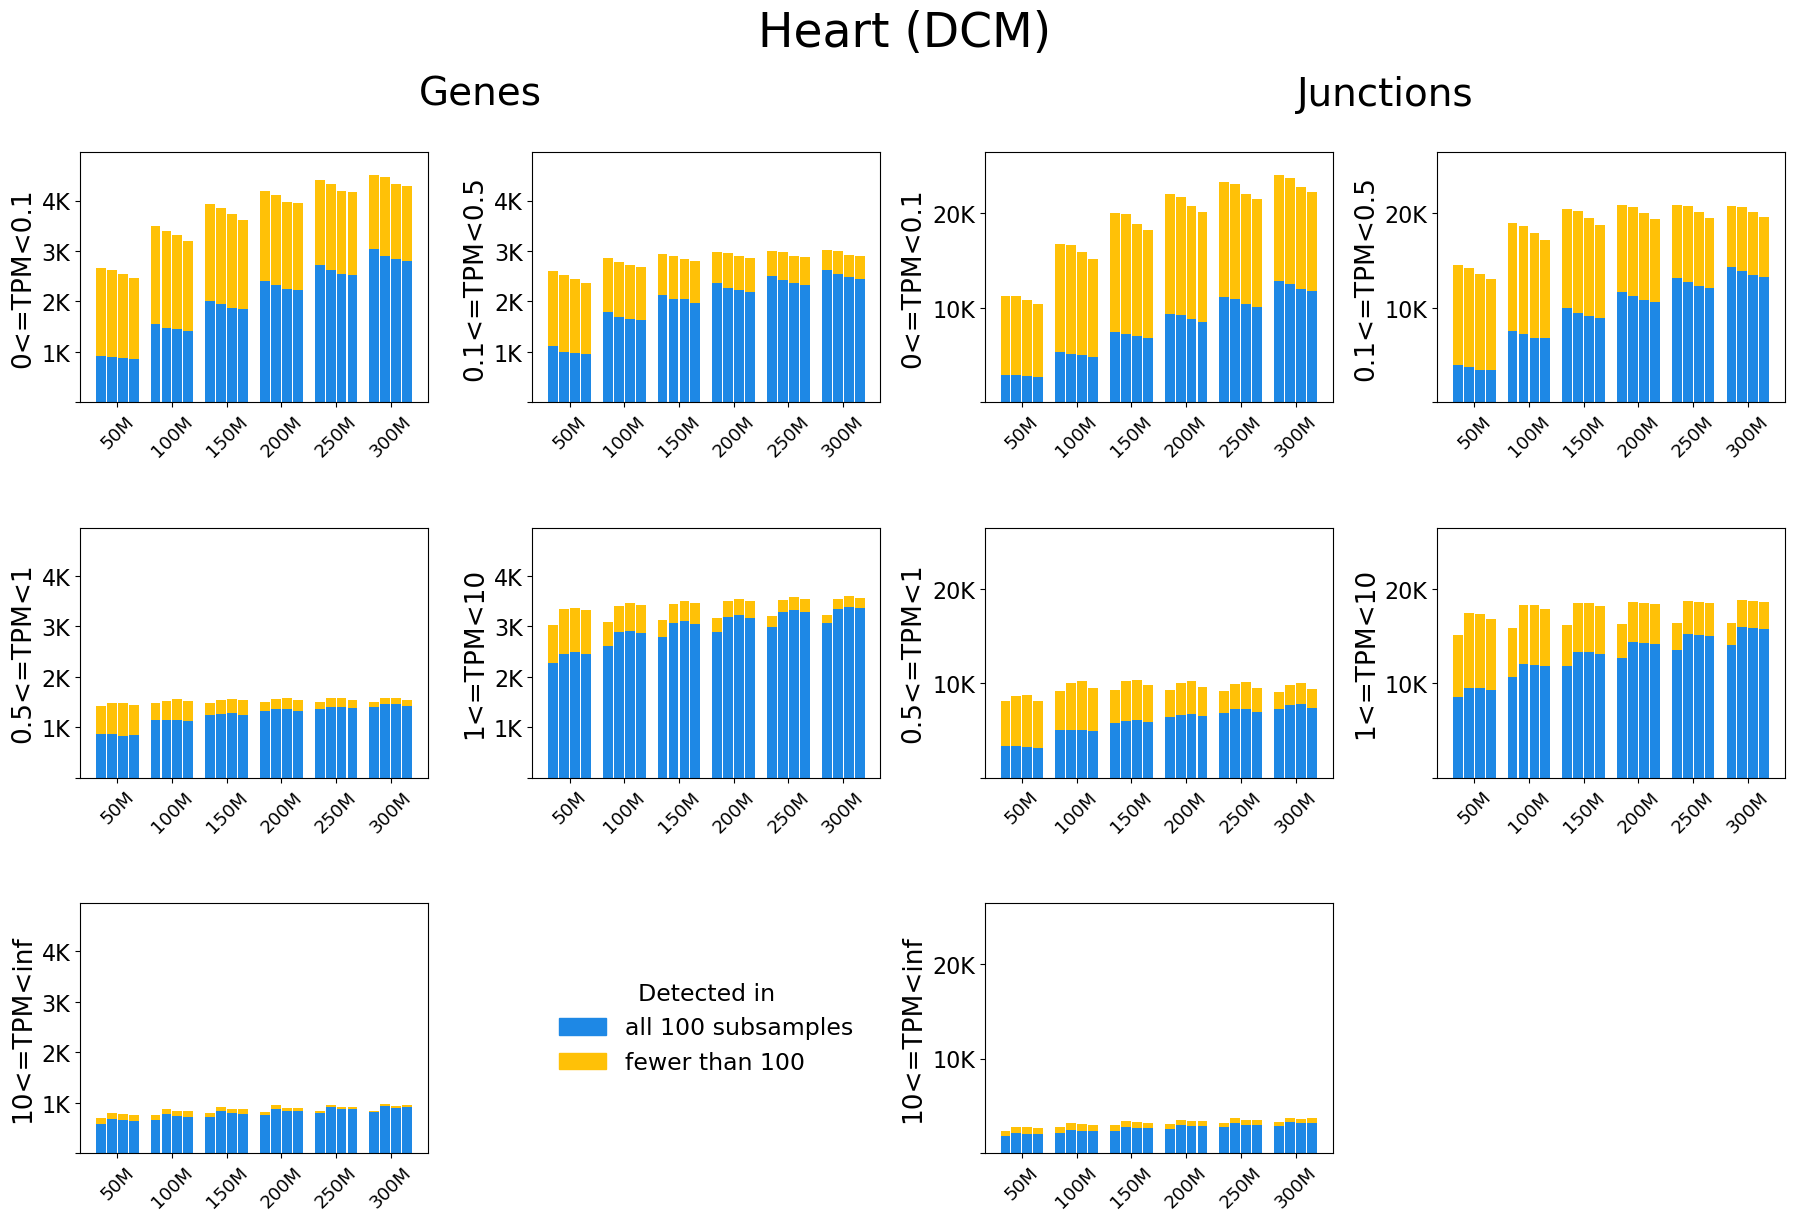

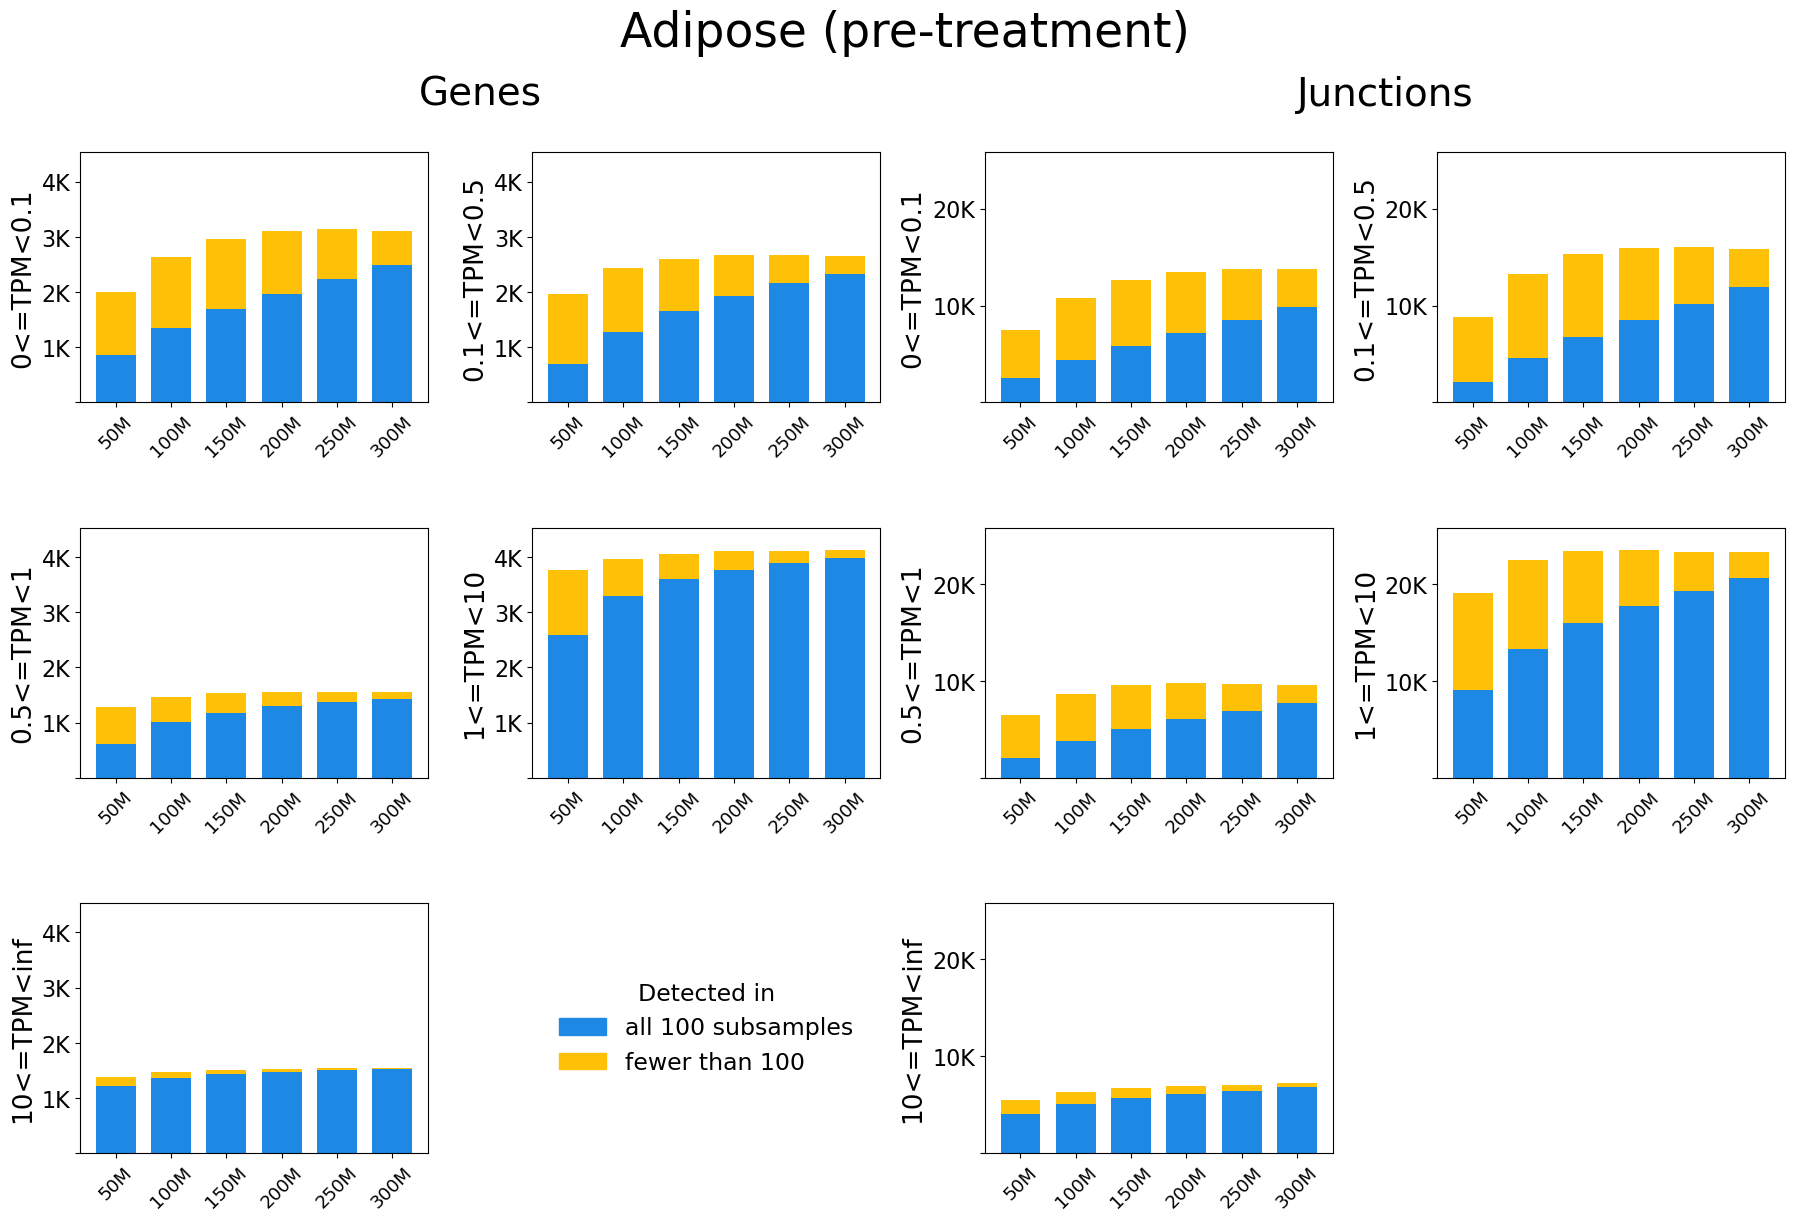

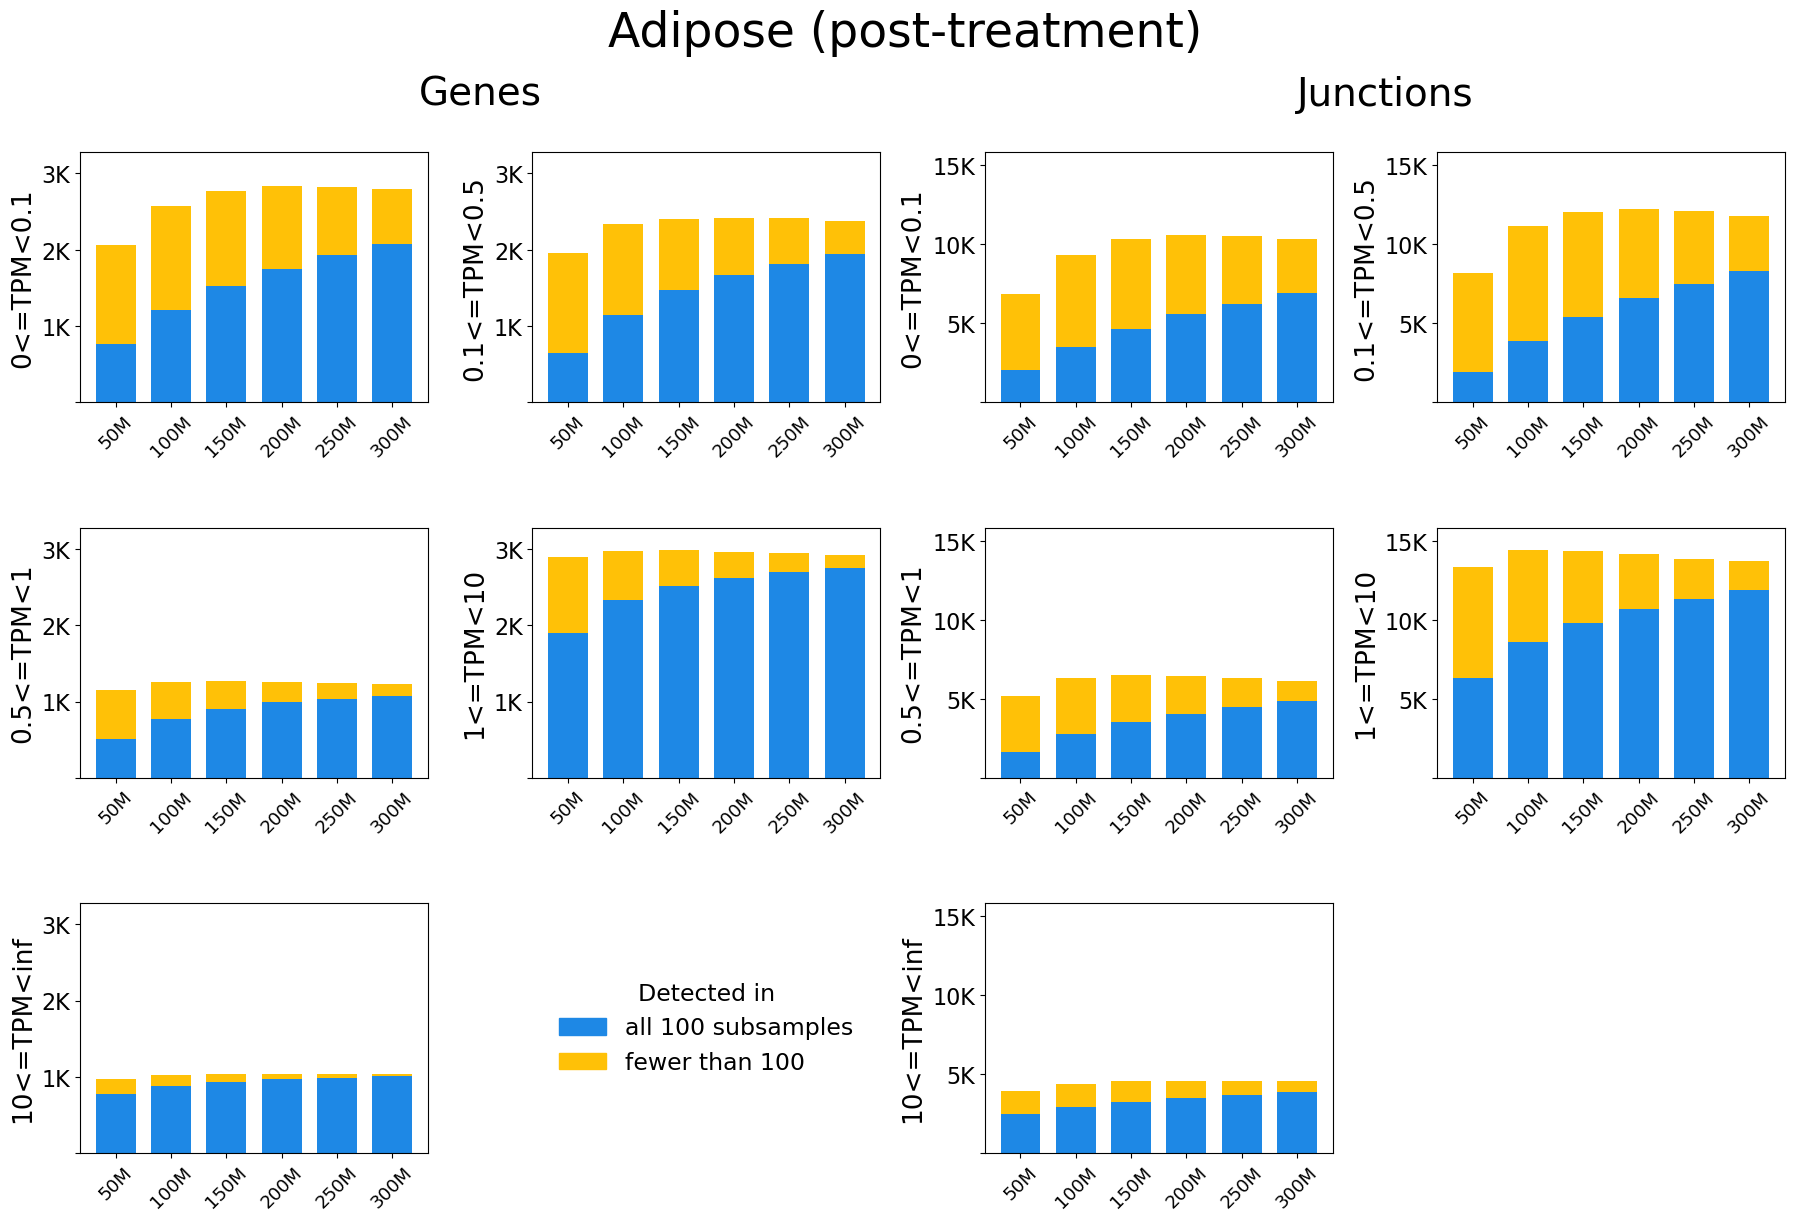

In [3]:
PANELS = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0)]


def plot_dataset(dataset):
    spec = DATASETS[dataset]
    per_sample = counts[dataset]
    depths = per_sample[0][CATEGORIES[0]].depths
    n_samples = len(per_sample)

    figure = plt.figure(figsize=(22, 13))
    grid = figure.add_gridspec(3, 4, hspace=0.5, wspace=0.3)
    figure.suptitle(spec["title"], fontsize=34, y=0.99)
    width = 0.8 / n_samples

    for side, kind in ((0, "genes"), (2, "junctions")):
        block = []
        ceiling = 1.1 * max(
            max(getattr(sample[category], f"all_{kind}"))
            for sample in per_sample
            for category in CATEGORIES
        )
        for category, (row, column) in zip(CATEGORIES, PANELS):
            axes = figure.add_subplot(grid[row, column + side])
            block.append(axes)
            for index, sample in enumerate(per_sample):
                offsets = np.arange(len(depths)) + index * width - 0.4 + width / 2
                robust = getattr(sample[category], f"robust_{kind}")
                sporadic = getattr(sample[category], f"sporadic_{kind}")
                axes.bar(offsets, robust, width=width * 0.9,
                         color=STACK_COLORS["robust"])
                axes.bar(offsets, sporadic, bottom=robust, width=width * 0.9,
                         color=STACK_COLORS["sporadic"])

            axes.set_xticks(np.arange(len(depths)))
            axes.set_xticklabels([f"{d}M" for d in depths], fontsize=13,
                                 rotation=45)
            axes.tick_params(axis="y", labelsize=16)
            axes.yaxis.set_major_formatter(plt.FuncFormatter(thousands))
            axes.set_ylabel(label(*category), fontsize=19)
            axes.set_ylim(0, ceiling)

        # Heading centred over the two columns this block occupies.
        boxes = [panel.get_position() for panel in block]
        figure.text(
            (min(b.x0 for b in boxes) + max(b.x1 for b in boxes)) / 2,
            max(b.y1 for b in boxes) + 0.03,
            kind.capitalize(), ha="center", va="bottom", fontsize=28,
        )

    # The layout leaves grid[2, 1] free, which is where the legend goes.
    legend = figure.add_subplot(grid[2, 1])
    legend.axis("off")
    legend.legend(
        handles=[
            plt.Rectangle((0, 0), 1, 1, color=STACK_COLORS["robust"]),
            plt.Rectangle((0, 0), 1, 1, color=STACK_COLORS["sporadic"]),
        ],
        labels=["all 100 subsamples", "fewer than 100"],
        title="Detected in", title_fontsize=17,
        fontsize=17, loc="center", frameon=False,
    )
    return figure


for dataset in ("heart_dcm", "adipose_pre", "adipose_post"):
    figure = plot_dataset(dataset)
    figure.savefig(RESULTS / f"Figure_3_{dataset}.png", dpi=300,
                   bbox_inches="tight")
    plt.show()

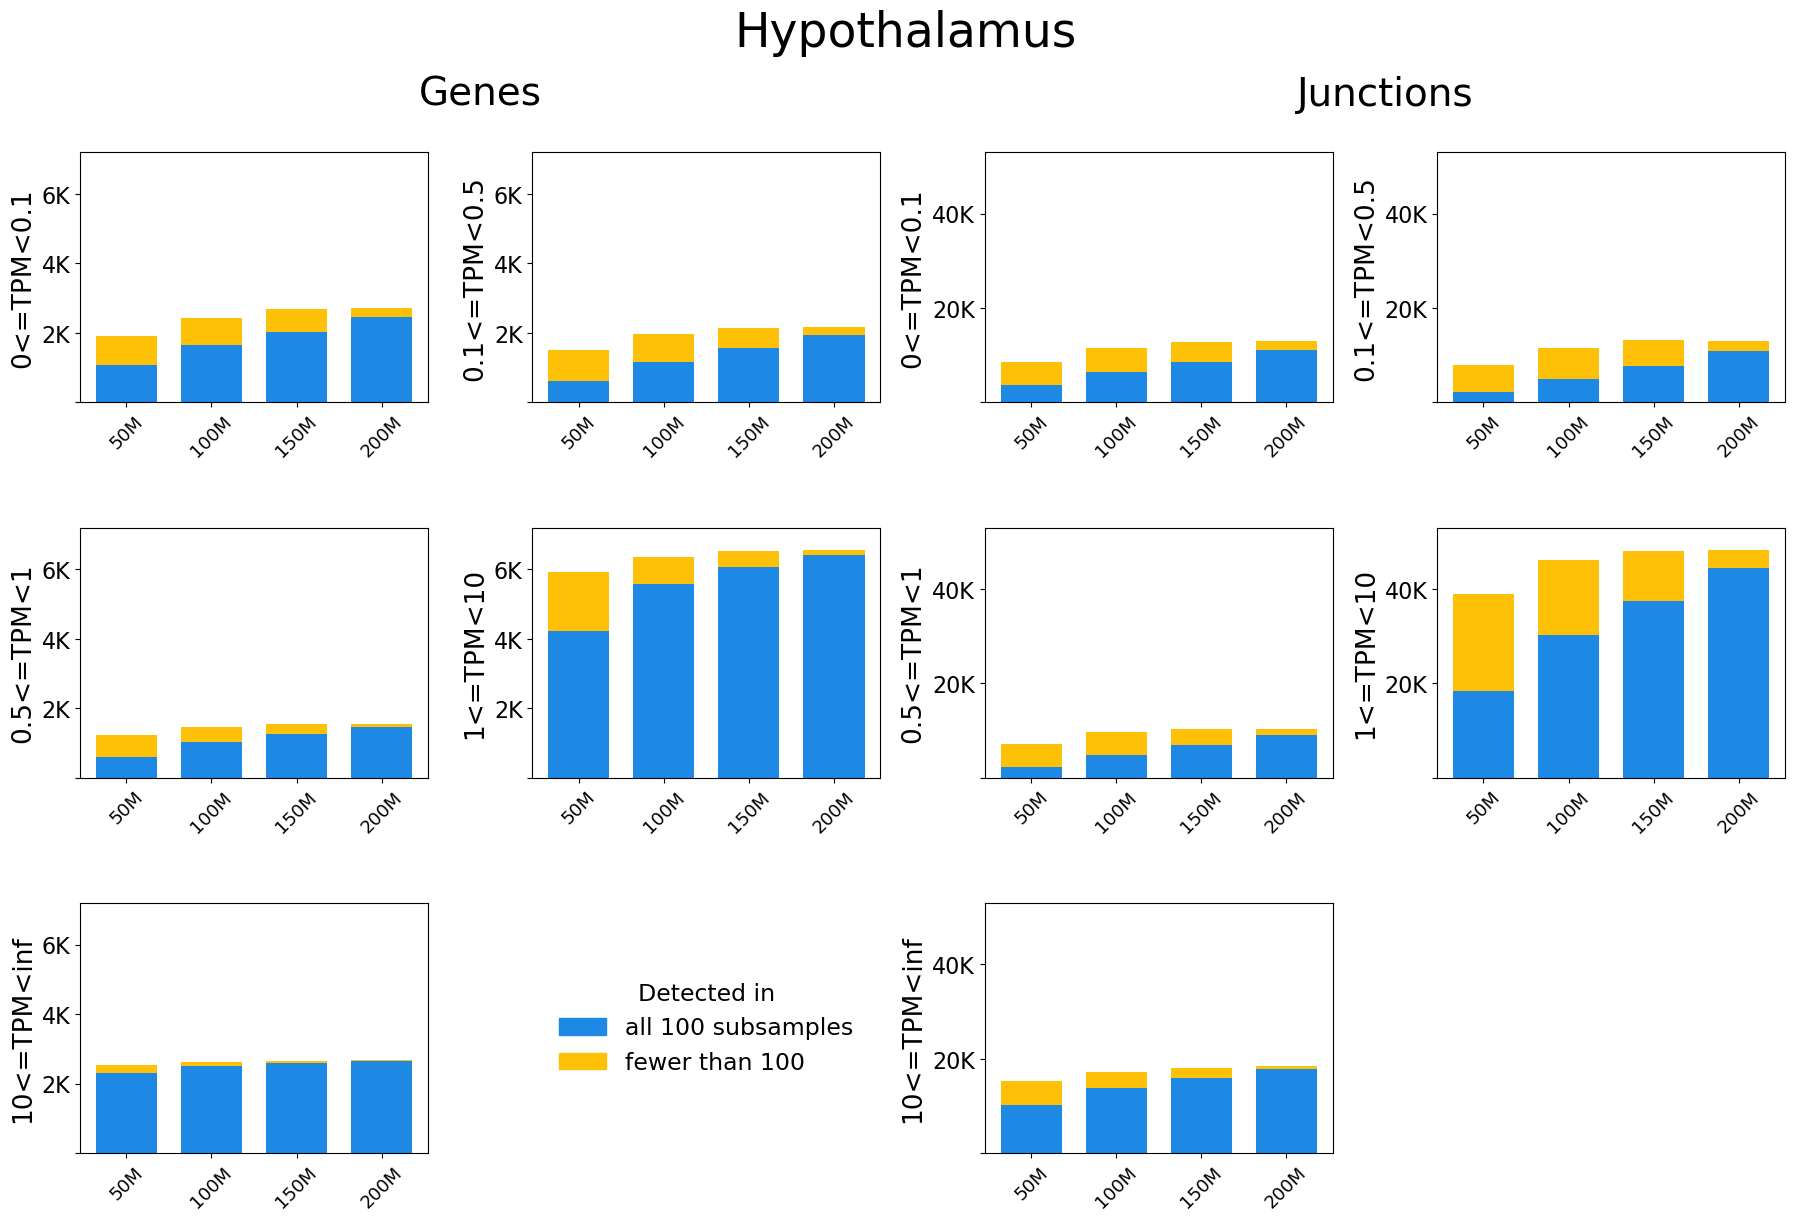

In [4]:
figure = plot_dataset("hypothalamus")
figure.savefig(RESULTS / "Figure_S3.png", dpi=300, bbox_inches="tight")
plt.show()

## Trend slopes

Mann-Kendall trend slopes, reported per sample and separately for genes and
junctions detected in all 100 subsamples and in at least one. Hypothalamus is
left out: with four depths it has too few points for the test, as the Methods
state.

In [5]:
TREND_TESTED = [d for d in DATASETS if d != "hypothalamus"]

rows = []
for dataset in TREND_TESTED:
    spec = DATASETS[dataset]
    for sample_name, sample in zip(spec["samples"], counts[dataset]):
        for category in CATEGORIES:
            for kind in ("genes", "junctions"):
                for scope, prefix in (("in at least one", "all"), ("in 100", "robust")):
                    series = getattr(sample[category], f"{prefix}_{kind}")
                    result = mk.original_test(series)
                    rows.append(
                        {
                            "dataset": spec["title"],
                            "sample": sample_name,
                            "kind": kind,
                            "scope": scope,
                            "category": label(*category),
                            "slope": result.slope,
                            "p": result.p,
                            "trend": result.trend,
                        }
                    )

table_s3 = pd.DataFrame(rows)
table_s3.to_csv(RESULTS / "Table_S3.tsv", sep="\t", index=False)
table_s3[table_s3["p"] < 0.05].round(3).head(20)

,dataset,sample,kind,scope,category,slope,p,trend
0,Heart (DCM),J26675,genes,in at least one,0<=TPM<0.1,304.667,0.009,increasing
1,Heart (DCM),J26675,genes,in 100,0<=TPM<0.1,394.000,0.009,increasing
2,Heart (DCM),J26675,junctions,in at least one,0<=TPM<0.1,2188.333,0.009,increasing
3,Heart (DCM),J26675,junctions,in 100,0<=TPM<0.1,1933.000,0.009,increasing
4,Heart (DCM),J26675,genes,in at least one,0.1<=TPM<0.5,41.667,0.009,increasing
5,Heart (DCM),J26675,genes,in 100,0.1<=TPM<0.5,236.667,0.009,increasing
7,Heart (DCM),J26675,junctions,in 100,0.1<=TPM<0.5,1865.000,0.009,increasing
8,Heart (DCM),J26675,genes,in at least one,0.5<=TPM<1,11.000,0.009,increasing
9,Heart (DCM),J26675,genes,in 100,0.5<=TPM<1,82.000,0.009,increasing
11,Heart (DCM),J26675,junctions,in 100,0.5<=TPM<1,625.000,0.009,increasing


## New detections between consecutive depths

New detections between consecutive depths, averaged over the samples of a
dataset and expressed as a percentage of the category total.
One table per dataset.

In [6]:
def increments_table(dataset):
    spec = DATASETS[dataset]
    per_sample = counts[dataset]
    depths = per_sample[0][CATEGORIES[0]].depths
    rows = []

    for kind in ("genes", "junctions"):
        for scope, prefix in (("In 100 subsamples", "robust"),
                              ("In at least one subsample", "all")):
            for category in CATEGORIES:
                total = TOTALS[dataset, kind, category_key(*category)]
                series = [
                    getattr(sample[category], f"{prefix}_{kind}")
                    for sample in per_sample
                ]
                averaged = [mean(values) for values in zip(*series)]
                row = {
                    "kind": kind,
                    "scope": scope,
                    "category": label(*category),
                    f"at {depths[0]}M": averaged[0],
                    f"at {depths[0]}M, %": averaged[0] / total * 100,
                    f"at {depths[-1]}M": averaged[-1],
                    f"at {depths[-1]}M, %": averaged[-1] / total * 100,
                }
                for start, end, gained in zip(depths, depths[1:], np.diff(averaged)):
                    row[f"{start}->{end}M"] = gained
                    row[f"{start}->{end}M, %"] = gained / total * 100
                rows.append(row)

    return pd.DataFrame(rows).set_index(["kind", "scope", "category"])


NAMES = {
    "heart_dcm": "Table_3",
    "adipose_pre": "Table_S4",
    "adipose_post": "Table_S5",
    "hypothalamus": "Table_S6",
}

tables = {}
for dataset, name in NAMES.items():
    tables[dataset] = increments_table(dataset)
    tables[dataset].round(2).to_csv(RESULTS / f"{name}.tsv", sep="\t")

tables["heart_dcm"].filter(regex=r"%$").round(2)

at 50M, %  at 300M, %  \
kind      scope                     category                              
genes     In 100 subsamples         0<=TPM<0.1         6.63       21.54   
                                    0.1<=TPM<0.5      20.75       51.68   
                                    0.5<=TPM<1        39.17       65.66   
                                    1<=TPM<10         48.64       66.24   
                                    10<=TPM<inf       48.32       67.92   
          In at least one subsample 0<=TPM<0.1        19.14       32.69   
                                    0.1<=TPM<0.5      50.80       60.43   
                                    0.5<=TPM<1        66.45       71.00   
                                    1<=TPM<10         65.77       70.27   
                                    10<=TPM<inf       57.59       70.89   
junctions In 100 subsamples         0<=TPM<0.1         2.60       11.40   
                                    0.1<=TPM<0.5       3.81       14.48   
                                    0.5<=TPM<1         6.20       14.29   
                                    1<=TPM<10          7.66       12.80   
                                    10<=TPM<inf        6.62       10.60   
          In at least one subsample 0<=TPM<0.1        10.15       21.56   
                                    0.1<=TPM<0.5      14.58       21.35   
                                    0.5<=TPM<1        15.94       18.17   
                                    1<=TPM<10         13.86       15.08   
                                    10<=TPM<inf        8.86       12.05   

                                                  50->100M, %  100->150M, %  \
kind      scope                     category                                  
genes     In 100 subsamples         0<=TPM<0.1           4.38          3.28   
                                    0.1<=TPM<0.5        13.92          7.12   
                                    0.5<=TPM<1          12.88          5.82   
                                    1<=TPM<10            8.05          3.63   
                                    10<=TPM<inf          7.21          4.27   
          In at least one subsample 0<=TPM<0.1           5.80          3.24   
                                    0.1<=TPM<0.5         5.71          2.27   
                                    0.5<=TPM<1           2.97          0.75   
                                    1<=TPM<10            1.58          0.88   
                                    10<=TPM<inf          5.78          2.75   
junctions In 100 subsamples         0<=TPM<0.1           2.15          1.87   
                                    0.1<=TPM<0.5         3.65          2.41   
                                    0.5<=TPM<1           3.31          1.74   
                                    1<=TPM<10            2.00          1.06   
                                    10<=TPM<inf          1.21          0.88   
          In at least one subsample 0<=TPM<0.1           4.84          2.92   
                                    0.1<=TPM<0.5         4.55          1.66   
                                    0.5<=TPM<1           2.52          0.29   
                                    1<=TPM<10            0.75          0.19   
                                    10<=TPM<inf          1.12          0.75   

                                                  150->200M, %  200->250M, %  \
kind      scope                     category                                   
genes     In 100 subsamples         0<=TPM<0.1            2.84          2.24   
                                    0.1<=TPM<0.5          4.56          2.91   
                                    0.5<=TPM<1            3.67          2.21   
                                    1<=TPM<10             2.44          2.02   
                                    10<=TPM<inf           3.35          2.52   
          In at least one subsample 0<=TPM<0.1            2.02          1.60   
                    